In [20]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TelecomChurnAnalysis") \
    .master("local[*]") \
    .getOrCreate()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml import pipeline
from pyspark.sql.functions import col, when, expr, sum as spark_sum
from pyspark.sql.types import *

In [24]:
df = spark.read.csv("telecom_churn-548e25b9-98ee-43b8-ad30-4f76940fb4e7.csv", header=True, inferSchema=True)
df.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|        TechSupport|        StreamingTV|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|  CUS00001|  Male|            0|    Yes|        No|    42|         Yes|              No|            DSL|                 No|                Yes|                Yes|      One year|             Yes|    Electronic check|         72.56|     305

In [25]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 7043
Columns: 18


In [26]:
missing = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
missing.show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|TechSupport|StreamingTV|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|          0|          0|       0|               0|            0|             0|          90|    0|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-------

In [27]:
for col_name in df.columns:
    null_count = df.filter(
        col(col_name).isNull() | (col(col_name).cast(StringType()) == '')
    ).count()
    if null_count > 0:
        print(col_name, "->", null_count, "missing values")

TotalCharges -> 90 missing values


In [28]:
df = df.withColumn("TotalCharges", expr("try_cast(TotalCharges as double)"))
df = df.fillna({"TotalCharges": 0.0})

In [29]:
df.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|        TechSupport|        StreamingTV|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|  CUS00001|  Male|            0|    Yes|        No|    42|         Yes|              No|            DSL|                 No|                Yes|                Yes|      One year|             Yes|    Electronic check|         72.56|     305

In [30]:
df.select("Churn").show()

+-----+
|Churn|
+-----+
|   No|
|  Yes|
|   No|
|   No|
|   No|
|  Yes|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
|  Yes|
|   No|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
+-----+
only showing top 20 rows


In [31]:
df = df.withColumn(
    'ChurnLabel',
    when(col('Churn') == 'Yes', 1.0).otherwise(0.0)
)

df.groupBy("ChurnLabel").count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 5277|
|       1.0| 1766|
+----------+-----+



In [32]:
df.select('Partner').show()

+-------+
|Partner|
+-------+
|    Yes|
|    Yes|
|     No|
|    Yes|
|    Yes|
|    Yes|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|    Yes|
+-------+
only showing top 20 rows


In [33]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [34]:
indexers = []
for c in cat_cols:
    idx = StringIndexer(inputCol= c , outputCol= c + '_idx', handleInvalid= 'keep')
    indexers.append(idx)
len(indexers)

12

In [35]:
encoders = []
for c in cat_cols:
    enc = OneHotEncoder(inputCol= c + '_idx',  outputCol= c + '_ohe', dropLast = True)
    encoders.append(enc)

len(encoders)

12

In [36]:
ohe_cols = [c + '_ohe' for c in cat_cols]
all_feature_cols = num_cols + ohe_cols

assembler = VectorAssembler(inputCols = all_feature_cols, outputCol= 'features', handleInvalid= 'keep')

In [37]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [38]:
from pyspark.ml import Pipeline

In [39]:
prep_pipeline = Pipeline(stages = indexers + encoders +[assembler])
prep_model = prep_pipeline.fit(df)
df_prep = prep_model.transform(df)
df_prep.select("InternetService_ohe").show(5)

+-------------------+
|InternetService_ohe|
+-------------------+
|      (3,[1],[1.0])|
|      (3,[0],[1.0])|
|      (3,[2],[1.0])|
|      (3,[2],[1.0])|
|      (3,[0],[1.0])|
+-------------------+
only showing top 5 rows


In [40]:
train_data , test_data = df_prep.randomSplit([0.7, 0.3], seed = 42)
print(train_data.count())
print(test_data.count())

26/06/16 11:34:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


5036
2007


In [41]:
train_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 3781|
|       1.0| 1255|
+----------+-----+



In [42]:
test_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 1496|
|       1.0|  511|
+----------+-----+



In [43]:
logR = LogisticRegression(
    labelCol= 'ChurnLabel',
    featuresCol= 'features',
    maxIter= 100,
    regParam = 0.01
)

print("Regression Model")

lr_model = logR.fit(train_data)
print(lr_model)

Regression Model


26/06/16 11:34:30 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


LogisticRegressionModel: uid=LogisticRegression_4ac6d2f7d84a, numClasses=2, numFeatures=36


In [44]:
lr_pred = lr_model.transform(test_data)

for c in lr_pred.columns[-5:]:
    print(c)

PaymentMethod_ohe
features
rawPrediction
probability
prediction


In [45]:
lr_pred.select (
'customerID', 'ChurnLabel', 'rawPrediction', "probability", 'prediction').show(5)

+----------+----------+--------------------+--------------------+----------+
|customerID|ChurnLabel|       rawPrediction|         probability|prediction|
+----------+----------+--------------------+--------------------+----------+
|  CUS00003|       0.0|[1.22555480001600...|[0.77303961345466...|       0.0|
|  CUS00007|       0.0|[2.23779686486223...|[0.90359270731639...|       0.0|
|  CUS00009|       1.0|[0.69730973030122...|[0.66759103509732...|       0.0|
|  CUS00010|       0.0|[1.70109732381818...|[0.84567799737913...|       0.0|
|  CUS00014|       0.0|[0.67944909609309...|[0.66361573027120...|       0.0|
+----------+----------+--------------------+--------------------+----------+
only showing top 5 rows


In [46]:
from pyspark.ml.evaluation import *

In [47]:
evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol='ChurnLabel', predictionCol='prediction', metricName='f1'
)

lr_f1_eval = evaluator_f1.evaluate(lr_pred)
print(lr_f1_eval)

0.6816304449219187


In [48]:
lr_TP = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 1)).count()
lr_TN = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 0)).count()
lr_FP = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 1)).count()
lr_FN = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 0)).count()


print("TP" , lr_TP)
print("TN", lr_TN)
print("FP", lr_FP)
print("FN", lr_FN)

TP 63
TN 1429
FP 67
FN 448


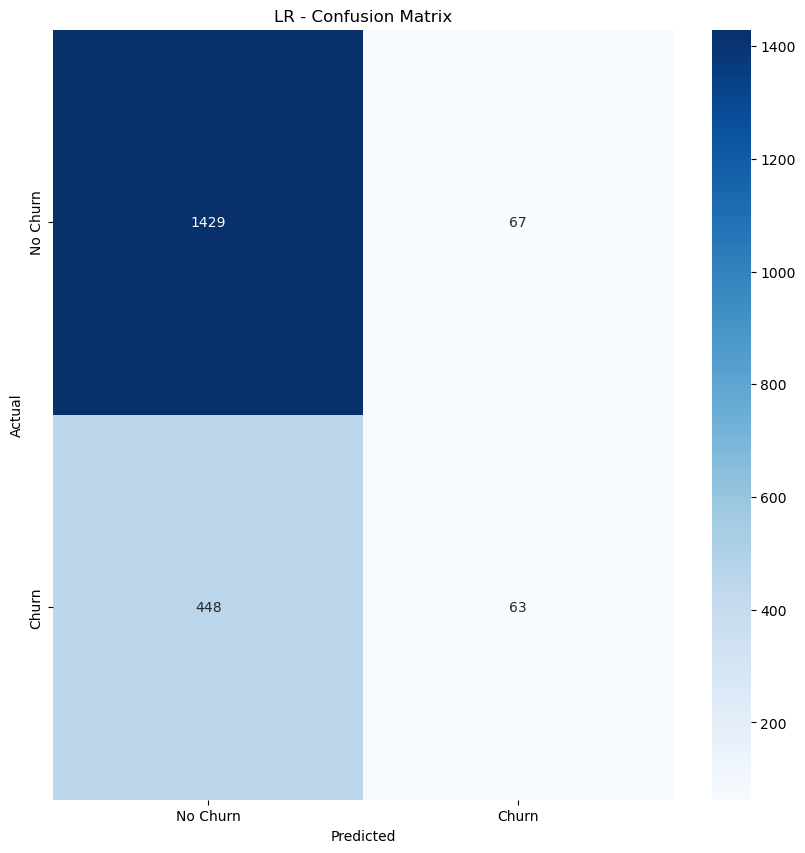

In [49]:
cm = np.array([[lr_TN, lr_FP], [lr_FN, lr_TP]])

plt.figure(figsize= (10,10))
sns.heatmap(cm , annot = True ,
           xticklabels= ["No Churn", 'Churn'],
           yticklabels=['No Churn', 'Churn'],
           cmap= 'Blues',
           fmt = "d")
plt.title("LR - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.show()

# Naive Bayes

In [50]:
from pyspark.ml.feature import StringIndexer, QuantileDiscretizer, VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml import Pipeline

In [51]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

In [52]:
indexers = [
    StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep') 
    for c in cat_cols
]

In [53]:
num_cols_to_bin = ['tenure', 'MonthlyCharges', 'TotalCharges']
discretizers = [
    QuantileDiscretizer(numBuckets=5, inputCol=c, outputCol=c + '_bin', handleInvalid='keep')
    for c in num_cols_to_bin
]

In [54]:
final_features = [c + '_idx' for c in cat_cols] + [c + '_bin' for c in num_cols_to_bin] + ['SeniorCitizen']

In [55]:
assembler = VectorAssembler(inputCols=final_features, outputCol='nb_features', handleInvalid='keep')

In [56]:
nb_prep_pipeline = Pipeline(stages=indexers + discretizers + [assembler])
nb_prep_model = nb_prep_pipeline.fit(df)
df_nb_prep = nb_prep_model.transform(df)

train_nb, test_nb = df_nb_prep.randomSplit([0.7, 0.3], seed=42)

In [57]:
nb = NaiveBayes(
    labelCol='ChurnLabel',
    featuresCol='nb_features',
    modelType='multinomial',
    smoothing=1.0
)

nb_model = nb.fit(train_nb)

In [58]:
nb_predictions = nb_model.transform(test_nb)

nb_predictions.select('customerID', 'ChurnLabel', 'rawPrediction', 'probability', 'prediction').show(5)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='ChurnLabel', predictionCol='prediction', metricName='f1'
)

nb_f1_score = evaluator_f1.evaluate(nb_predictions)
print("Multinomial Naive Bayes F1 Score:", nb_f1_score)

+----------+----------+--------------------+--------------------+----------+
|customerID|ChurnLabel|       rawPrediction|         probability|prediction|
+----------+----------+--------------------+--------------------+----------+
|  CUS00003|       0.0|[-46.058118718829...|[0.80317225402407...|       0.0|
|  CUS00007|       0.0|[-24.225715944841...|[0.93685773826518...|       0.0|
|  CUS00009|       1.0|[-37.179486553084...|[0.69776661832025...|       0.0|
|  CUS00010|       0.0|[-26.526735671186...|[0.92021572786797...|       0.0|
|  CUS00014|       0.0|[-21.269316650511...|[0.65064605746029...|       0.0|
+----------+----------+--------------------+--------------------+----------+
only showing top 5 rows
Multinomial Naive Bayes F1 Score: 0.6512020203875347


TP: 22 | TN: 1459 | FP: 37 | FN: 489


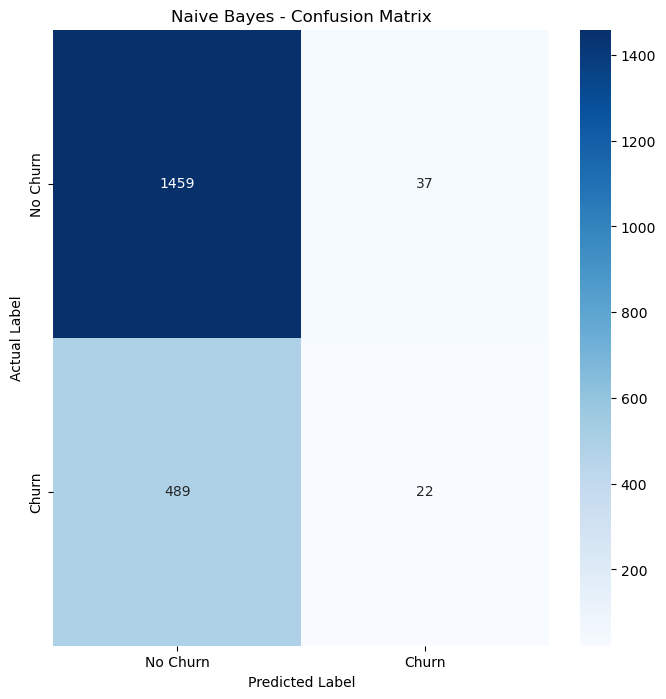

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

nb_TP = nb_predictions.filter((col('ChurnLabel') == 1) & (col('prediction') == 1)).count()
nb_TN = nb_predictions.filter((col('ChurnLabel') == 0) & (col('prediction') == 0)).count()
nb_FP = nb_predictions.filter((col('ChurnLabel') == 0) & (col('prediction') == 1)).count()
nb_FN = nb_predictions.filter((col('ChurnLabel') == 1) & (col('prediction') == 0)).count()

print(f"TP: {nb_TP} | TN: {nb_TN} | FP: {nb_FP} | FN: {nb_FN}")

cm_nb = np.array([[nb_TN, nb_FP], [nb_FN, nb_TP]])

plt.figure(figsize=(8, 8))
sns.heatmap(cm_nb, annot=True,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            cmap="Blues",
            fmt="d")
plt.title("Naive Bayes - Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel("Predicted Label")
plt.savefig("nb_confusion_matrix.png")

Multinomial Naive Bayes AUC Score: 0.6833


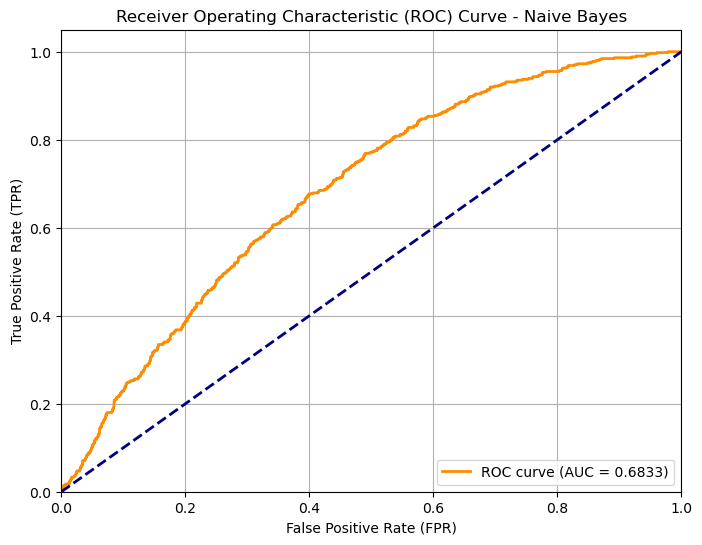

In [60]:
from sklearn.metrics import roc_curve, auc

eval_df = nb_predictions.select('ChurnLabel', 'probability').toPandas()

eval_df['pos_prob'] = eval_df['probability'].apply(lambda x: x[1])

fpr, tpr, thresholds = roc_curve(eval_df['ChurnLabel'], eval_df['pos_prob'])

roc_auc = auc(fpr, tpr)
print(f"Multinomial Naive Bayes AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("nb_roc_curve.png")